# Experiment 08 – Clustering and Dimensionality Reduction

## Aim

To apply clustering and dimensionality reduction techniques to the Pima Indians Diabetes Dataset to discover hidden patterns and visualize relationships among patients.

## Objectives

1. Apply clustering and dimensionality reduction techniques to discover patterns in a high-dimensional dataset.
2. Interpret the resulting clusters and reduced-dimensional representations using suitable evaluation measures and visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
sns.set_theme(style="whitegrid")

In [2]:
uploaded = files.upload()
df = pd.read_csv("diabetes.csv")
print("Dataset loaded successfully.")
display(df.head())

Saving diabetes.csv to diabetes.csv
Dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [4]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]
df_clustering = df[features].copy()
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
df_clustering[invalid_columns] = df_clustering[invalid_columns].replace(
    0, np.nan
)
for column in invalid_columns:
    df_clustering[column] = df_clustering[column].fillna(
        df_clustering[column].median()
    )
print("Invalid values handled successfully.")
print("\nRemaining missing values:")
print(df_clustering.isnull().sum())

Invalid values handled successfully.

Remaining missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)
print("Standardization completed.")
display(X_scaled.head())

Standardization completed.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.864625,-0.032180,0.665181,0.311604,0.169483,0.468492,1.425995
1,-0.844885,-1.204727,-0.528124,-0.010112,-0.440843,-0.848549,-0.365061,-0.190672
2,1.233880,2.014265,-0.693438,0.327535,0.311604,-1.328478,0.604397,-0.105584
3,-0.844885,-1.073339,-0.528124,-0.685405,-0.536303,-0.630399,-0.920763,-1.041549
4,-1.141852,0.503310,-2.677212,0.665181,0.294758,1.551096,5.484909,-0.020496


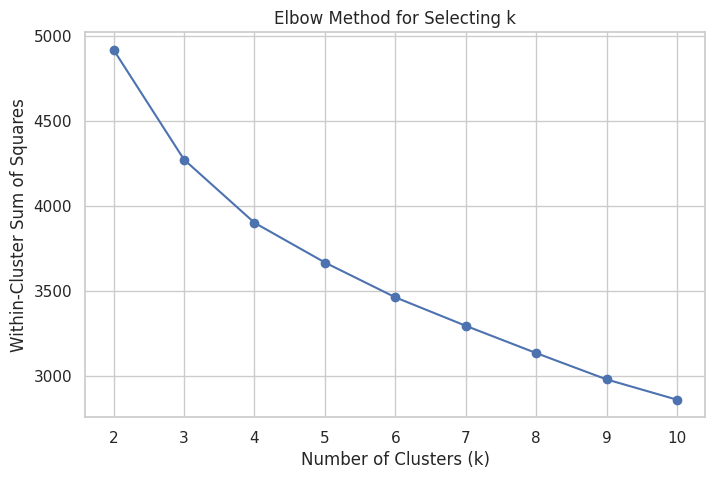

In [6]:
inertia_values = []
k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.title("Elbow Method for Selecting k")
plt.xticks(k_values)
plt.show()

In [7]:
optimal_k = 3
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(X_scaled)
df_clustered = df.copy()
df_clustered["Cluster"] = clusters
print("K-Means clustering completed.")
print("\nCluster Counts:")
print(df_clustered["Cluster"].value_counts().sort_index())

K-Means clustering completed.

Cluster Counts:
Cluster
0    254
1    341
2    173
Name: count, dtype: int64


In [8]:
silhouette = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.2033


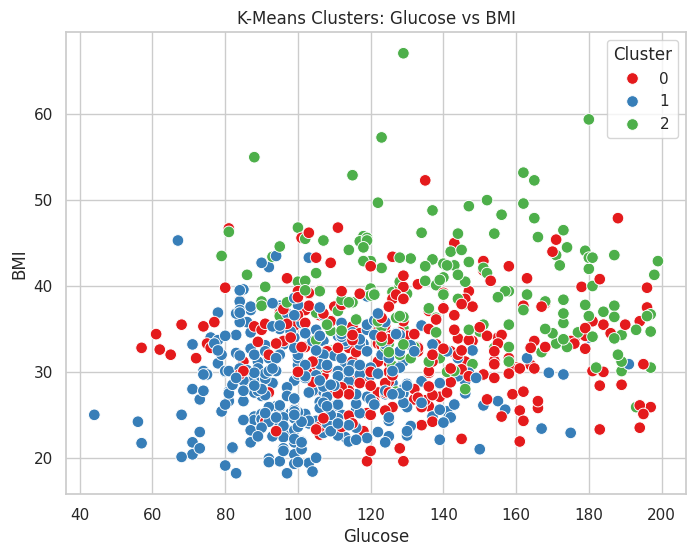

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clustered,
    x="Glucose",
    y="BMI",
    hue="Cluster",
    palette="Set1",
    s=70
)
plt.title("K-Means Clusters: Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.legend(title="Cluster")
plt.show()

In [10]:
cluster_outcome = pd.crosstab(
    df_clustered["Cluster"],
    df_clustered["Outcome"]
)
cluster_outcome.columns = [
    "Non-diabetic (0)",
    "Diabetic (1)"
]
display(cluster_outcome)

,Non-diabetic (0),Diabetic (1)
Cluster,,
0,127,127
1,302,39
2,71,102


In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)
pca_df["Cluster"] = clusters
pca_df["Outcome"] = df["Outcome"].values
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print(
    f"\nTotal variance explained by PC1 and PC2: "
    f"{pca.explained_variance_ratio_.sum():.4f}"
)

Explained variance ratio:
[0.29817668 0.18752573]

Total variance explained by PC1 and PC2: 0.4857


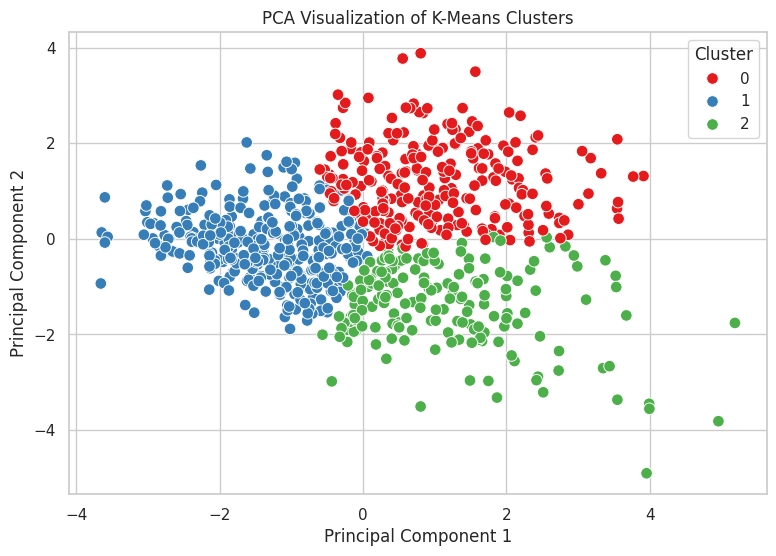

In [12]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=70
)
plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

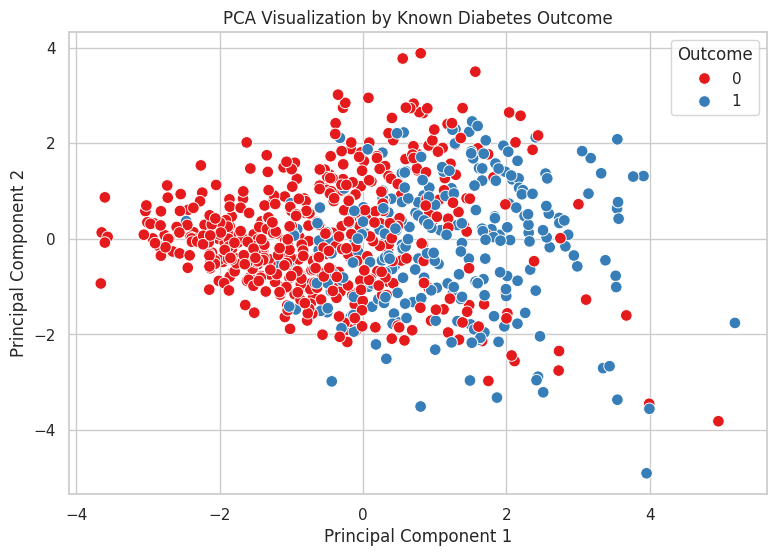

In [13]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Outcome",
    palette="Set1",
    s=70
)
plt.title("PCA Visualization by Known Diabetes Outcome")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Outcome")
plt.show()

In [14]:
cluster_means = df_clustered.groupby("Cluster")[features].mean()
display(cluster_means)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,7.358268,129.665354,78.078740,30.417323,144.868110,32.741339,0.451965,45.496063
1,2.170088,105.618768,66.914956,24.222874,104.444282,28.754839,0.411079,26.017595
2,1.988439,141.601156,74.826590,36.734104,210.722543,39.237572,0.620948,29.485549


## Conclusion

K-Means clustering was applied to the Pima Indians Diabetes Dataset after preprocessing and standardizing the medical features. The Elbow Method was used to examine different cluster counts, and the Silhouette Score was used to evaluate the resulting clustering.

PCA was then applied to reduce the standardized dataset to two principal components for visualization. The PCA representations helped visualize the discovered clusters and compare them with the known diabetes outcome categories.

The experiment demonstrated how clustering and dimensionality reduction can be used to discover and visualize patterns in a high-dimensional dataset.